## Multi-Agent Clinical Triage & Care Coordination System


In [158]:
!pip install -q langgraph langchain langchain-google-genai

In [159]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
import os

In [160]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0
)

In [161]:
#state definition
class ClinicalState(TypedDict):

    # --- Input ---
    symptoms_text: str
    patient_history: str
    # --- Stage 1: Symptom Understanding ---
    extracted_symptoms: str
    severity_level: str
    is_emergency: bool
    risk_score: int
    medical_entities: str
    distress_level: str
    symptom_category: str

    # --- Stage 2: Knowledge Retrieval ---
    medical_guidelines: str
    specialist_recommendation: str
    drug_interactions: str
    historical_cases: str

    # --- Stage 3: Routing & Agents ---
    route: str
    agent_assessment: str

    # --- Stage 4: Care Coordination ---
    triage_summary: str
    suggested_specialist: str
    followup_instructions: str
    diagnostic_tests: str
    emergency_notification: str
    final_report: str


### STAGE 1 — Symptom Understanding

In [162]:
def symptom_understanding(state: ClinicalState):
    """Single LLM call that performs full Stage 1 NLP understanding.

    Extracts: symptoms, severity, emergency flag, risk score,
    medical entities, distress level, and symptom category.
    """

    text = state["symptoms_text"]
    history = state.get("patient_history", "Not provided")

    prompt = f"""
    You are a clinical triage AI assistant.

    Analyze the patient's submitted symptoms and extract structured clinical information.

    Patient Complaint:
    {text}

    Patient History:
    {history}

    Return ONLY in this exact format (no extra text):

    extracted_symptoms: <comma-separated list of identified symptoms>
    severity_level: <critical / high / medium / low>
    is_emergency: <true / false>
    risk_score: <integer 0-100>
    medical_entities: <comma-separated body parts, conditions, medications mentioned>
    distress_level: <high / moderate / low>
    symptom_category: <cardiac / neuro / medication_reaction / respiratory / general>
    """

    response = llm.invoke(prompt)
    text_out = response.content

    result = {}
    for line in text_out.strip().split("\n"):
        if ":" in line:
            key, value = line.split(":", 1)
            result[key.strip()] = value.strip()

    return {
        "extracted_symptoms": result.get("extracted_symptoms", text),
        "severity_level": result.get("severity_level", "medium"),
        "is_emergency": result.get("is_emergency", "false").lower() == "true",
        "risk_score": int(result.get("risk_score", 50)),
        "medical_entities": result.get("medical_entities", ""),
        "distress_level": result.get("distress_level", "moderate"),
        "symptom_category": result.get("symptom_category", "general")
    }

In [163]:
def symptom_extraction(state: ClinicalState):
    """Rule-based: enriches extracted_symptoms with structured formatting.
    No LLM — uses the already-extracted symptom string from symptom_understanding.
    """

    raw = state.get("extracted_symptoms", "")
    symptoms = [s.strip() for s in raw.split(",") if s.strip()]

    formatted = "\n  • ".join(symptoms) if symptoms else "No symptoms extracted"
    formatted = "  • " + formatted

    return {
        "extracted_symptoms": formatted
    }

In [164]:
def risk_scoring(state: ClinicalState):
    """Rule-based: adjusts risk_score using keyword boosters on top of LLM base score.
    No LLM.
    """

    text = state["symptoms_text"].lower()
    base_score = state.get("risk_score", 50)

    # High-risk keywords
    critical_keywords = [
        "chest pain", "heart attack", "cannot breathe", "shortness of breath",
        "stroke", "unconscious", "severe bleeding", "paralysis", "seizure",
        "blurred vision", "sudden dizziness", "difficulty speaking"
    ]
    high_keywords = [
        "fever", "vomiting", "persistent", "severe", "extreme", "unbearable",
        "allergic reaction", "swelling", "palpitations"
    ]
    low_keywords = ["mild", "slight", "minor", "small", "little", "itching", "rash"]

    boost = 0
    for kw in critical_keywords:
        if kw in text:
            boost += 15
    for kw in high_keywords:
        if kw in text:
            boost += 5
    for kw in low_keywords:
        if kw in text:
            boost -= 10

    final_score = min(100, max(0, base_score + boost))

    return {
        "risk_score": final_score
    }

In [165]:
def medical_entity_recognition(state: ClinicalState):
    """Rule-based: scans the complaint for known medical terms and body parts.
    Augments the LLM-extracted medical_entities. No LLM.
    """

    text = state["symptoms_text"].lower()
    existing = state.get("medical_entities", "")

    body_parts = {
        "head", "chest", "heart", "lung", "stomach", "abdomen", "arm", "leg",
        "back", "neck", "throat", "eye", "vision", "brain", "skin", "liver",
        "kidney", "spine", "shoulder", "knee"
    }
    conditions = {
        "diabetes", "hypertension", "asthma", "allergy", "migraine", "epilepsy",
        "arthritis", "anxiety", "depression", "covid", "flu", "pneumonia"
    }
    medications = {
        "aspirin", "ibuprofen", "paracetamol", "antibiotic", "insulin",
        "blood pressure", "steroid", "metformin", "warfarin", "penicillin"
    }

    found_parts = [p for p in body_parts if p in text]
    found_conditions = [c for c in conditions if c in text]
    found_meds = [m for m in medications if m in text]

    recognized = []
    if found_parts:
        recognized.append(f"Body parts: {', '.join(found_parts)}")
    if found_conditions:
        recognized.append(f"Conditions: {', '.join(found_conditions)}")
    if found_meds:
        recognized.append(f"Medications: {', '.join(found_meds)}")

    additional = " | ".join(recognized) if recognized else "No additional entities detected"
    combined = f"{existing} | Rule-based NER: {additional}" if existing else f"Rule-based NER: {additional}"

    return {
        "medical_entities": combined
    }

In [166]:
def distress_analysis(state: ClinicalState):
    """Rule-based: refines distress_level using sentiment keywords.
    Overrides LLM estimate if strong signals are found. No LLM.
    """

    text = state["symptoms_text"].lower()
    current = state.get("distress_level", "moderate")

    high_distress = [
        "cant breathe", "can't breathe", "dying", "terrible", "worst",
        "unbearable", "help", "emergency", "please", "scared", "terrified"
    ]
    low_distress = [
        "mild", "slight", "a bit", "not too bad", "minor", "manageable", "okay"
    ]

    if any(kw in text for kw in high_distress):
        distress = "high"
    elif any(kw in text for kw in low_distress):
        distress = "low"
    else:
        distress = current

    return {
        "distress_level": distress
    }

In [167]:
def severity_classifier(state: ClinicalState):
    """
    Finalizes severity_level and is_emergency based on all collected signals.
    No LLM.
    """

    risk = state.get("risk_score", 50)
    current_severity = state.get("severity_level", "medium")
    is_emergency = state.get("is_emergency", False)

    # Override severity from final risk score
    if risk >= 80 or is_emergency:
        severity = "critical"
        is_emergency = True
    elif risk >= 60:
        severity = "high"
    elif risk >= 35:
        severity = "medium"
    else:
        severity = "low"

    return {
        "severity_level": severity,
        "is_emergency": is_emergency
    }

### STAGE 2 — Knowledge Retrieval


In [168]:
def should_retrieve(state: ClinicalState) -> str:
    """Conditional edge: emergencies skip retrieval to save time."""

    if state.get("is_emergency", False):
        return "skip_retrieval"
    else:
        return "run_retrieval"

In [169]:
def fetch_medical_guidelines(state: ClinicalState):
    """Rule-based: returns relevant clinical guidelines based on symptom category.
    No LLM — simulates a medical knowledge base lookup.
    """

    category = state.get("symptom_category", "general").lower()
    severity = state.get("severity_level", "medium").lower()

    GUIDELINES = {
        "cardiac": (
            "WHO Cardiac Triage Protocol: Administer 300mg aspirin if not contraindicated. "
            "12-lead ECG within 10 minutes. Troponin levels to be drawn immediately. "
            "Continuous BP monitoring required."
        ),
        "neuro": (
            "AHA Stroke Protocol (FAST): Face drooping, Arm weakness, Speech difficulty, Time to call. "
            "CT scan without contrast within 25 minutes of arrival. "
            "NIHSS scoring to assess stroke severity. tPA window: 3–4.5 hours from onset."
        ),
        "medication_reaction": (
            "Allergy & Anaphylaxis Protocol: Assess for anaphylaxis — epinephrine if indicated. "
            "Discontinue suspected medication. Antihistamines for mild reactions. "
            "Skin patch test and allergy panel recommended post-stabilization."
        ),
        "respiratory": (
            "Respiratory Distress Guidelines: SpO2 monitoring — administer O2 if below 94%. "
            "Peak flow measurement. Consider CPAP for severe cases. "
            "Chest X-ray and ABG analysis recommended."
        ),
        "general": (
            "General Triage Guidelines: Vital signs — BP, HR, Temperature, SpO2. "
            "Symptom duration and progression assessment. "
            "Pain scale 0–10 rating. Patient medical history review."
        )
    }

    base = GUIDELINES.get(category, GUIDELINES["general"])
    suffix = " — EXPEDITED PROTOCOL ACTIVATED." if severity in ["critical", "high"] else ""

    return {
        "medical_guidelines": base + suffix
    }

In [170]:
def fetch_specialist_recommendation(state: ClinicalState):
    """Rule-based: recommends specialist department based on category + severity.
    No LLM.
    """

    category = state.get("symptom_category", "general").lower()
    severity = state.get("severity_level", "medium").lower()

    SPECIALIST_MAP = {
        "cardiac":              "Cardiology Department — Senior Cardiologist",
        "neuro":                "Neurology Department — Neurologist / Stroke Team",
        "medication_reaction":  "Clinical Pharmacy & Allergy / Immunology",
        "respiratory":          "Pulmonology / Respiratory Medicine",
        "general":              "General Internal Medicine / Primary Care Physician"
    }

    dept = SPECIALIST_MAP.get(category, SPECIALIST_MAP["general"])

    if severity in ["critical", "high"]:
        dept = "EMERGENCY DEPARTMENT → " + dept

    return {
        "specialist_recommendation": dept
    }

In [171]:
def fetch_drug_interactions(state: ClinicalState):
    """Rule-based: checks for known drug interaction flags in the complaint.
    No LLM — simulates a drug interaction database lookup.
    """

    text = state["symptoms_text"].lower()
    history = state.get("patient_history", "").lower()
    combined = text + " " + history

    INTERACTIONS = [
        ("aspirin",    "warfarin",    "HIGH RISK — Aspirin + Warfarin: increased bleeding risk."),
        ("ibuprofen",  "blood pressure", "MODERATE — NSAIDs may reduce antihypertensive efficacy."),
        ("penicillin", "allergy",     "ALERT — Penicillin allergy flag. Cross-reactivity risk with cephalosporins."),
        ("metformin",  "contrast",    "CAUTION — Metformin should be withheld before contrast imaging."),
        ("steroid",    "diabetes",    "MONITOR — Corticosteroids can elevate blood glucose in diabetic patients."),
        ("aspirin",    "asthma",      "CAUTION — Aspirin-exacerbated respiratory disease (AERD) risk."),
    ]

    flags = []
    for drug1, drug2, warning in INTERACTIONS:
        if drug1 in combined and drug2 in combined:
            flags.append(warning)

    result = "\n".join(flags) if flags else "No drug interactions flagged based on reported information."

    return {
        "drug_interactions": result
    }

In [172]:
def fetch_historical_cases(state: ClinicalState):
    """Rule-based: returns similar historical case patterns for clinical reference.
    No LLM — simulates a case database lookup.
    """

    category = state.get("symptom_category", "general").lower()
    severity = state.get("severity_level", "medium").lower()

    CASES = {
        "cardiac": (
            "Similar Case: 58M with chest pain + dyspnea — diagnosed STEMI. "
            "PCI performed within 90 min. Full recovery. Key learning: ECG within 10 min critical."
        ),
        "neuro": (
            "Similar Case: 65F with sudden dizziness + slurred speech — ischemic stroke. "
            "tPA administered within 2h. Partial recovery. Key learning: FAST assessment saved outcome."
        ),
        "medication_reaction": (
            "Similar Case: 32M with rash + urticaria after antibiotic — mild anaphylaxis. "
            "Epinephrine + antihistamines. Discharged same day. Key learning: always elicit allergy history."
        ),
        "respiratory": (
            "Similar Case: 44F with persistent cough + breathlessness — community-acquired pneumonia. "
            "Antibiotics + O2 therapy. Discharged in 5 days. Key learning: CXR is diagnostic."
        ),
        "general": (
            "Similar Cases: fever + headache pattern common in viral syndromes (influenza, dengue). "
            "CBC and dengue NS1 recommended if fever >3 days. Symptomatic management in mild cases."
        )
    }

    case_ref = CASES.get(category, CASES["general"])
    urgency_note = " [High urgency — expedited workup recommended.]" if severity in ["critical", "high"] else ""

    return {
        "historical_cases": case_ref + urgency_note
    }

### STAGE 3 — Intelligent Routing & Specialist Agents


In [173]:
def intelligent_router(state: ClinicalState):
    """Rule-based routing

    Priority order:
      1. Emergency flag       → emergency_agent
      2. Cardiac category     → cardiology_agent
      3. Neuro category       → neuro_agent
      4. Medication reaction  → pharmacy_agent
      5. Default              → general_physician_agent
    """

    is_emergency = state.get("is_emergency", False)
    category = state.get("symptom_category", "general").lower()
    severity = state.get("severity_level", "medium").lower()
    risk = state.get("risk_score", 50)

    if is_emergency or severity == "critical" or risk >= 80:
        route = "emergency_agent"
    elif category == "cardiac":
        route = "cardiology_agent"
    elif category == "neuro":
        route = "neuro_agent"
    elif category == "medication_reaction":
        route = "pharmacy_agent"
    else:
        route = "general_physician_agent"

    return {"route": route}


def route_decision(state: ClinicalState) -> str:
    """Conditional edge selector — reads the route field set by intelligent_router."""
    return state["route"]

In [174]:
def _call_specialist_llm(role: str, context: str, state: ClinicalState) -> str:
    """Shared LLM call used by all specialist agents.
    Builds a rich prompt from collected state to generate a quality clinical assessment.
    """

    prompt = f"""
    You are a {role} at a hospital.

    A patient has been triaged to your department. Provide a concise clinical assessment.

    Patient Complaint:
    {state['symptoms_text']}

    Identified Symptoms:
    {state.get('extracted_symptoms', '')}

    Severity: {state.get('severity_level', '').upper()} | Risk Score: {state.get('risk_score', 0)}/100
    Medical Entities: {state.get('medical_entities', '')}
    Drug Interaction Flags: {state.get('drug_interactions', 'None')}
    Relevant Guidelines: {state.get('medical_guidelines', '')}
    Historical Reference: {state.get('historical_cases', '')}

    {context}

    Provide:
    1. Immediate clinical assessment
    2. Urgent actions to take
    3. Reassurance message for the patient (1–2 sentences)

    Be concise, structured, and clinically accurate.
    """

    response = llm.invoke(prompt)
    return response.content

In [175]:
import warnings

# Emergency Agent — critical / is_emergency=True path
def emergency_agent(state: ClinicalState):
    """ Highest priority — fast clinical response."""

    assessment = _call_specialist_llm(
        role="Emergency Medicine Physician",
        context="This is a CRITICAL EMERGENCY. Focus on immediate life-saving actions.",
        state=state
    )

    return {
        "agent_assessment": assessment
    }

In [176]:
# Cardiology Agent
def cardiology_agent(state: ClinicalState):
    """LLM Call #2 (cardiology path)."""

    assessment = _call_specialist_llm(
        role="Senior Cardiologist",
        context="Focus on cardiac differential diagnosis and cardiac-specific investigations.",
        state=state
    )

    return {
        "agent_assessment": assessment
    }

In [177]:
# Neuro Specialist Agent
def neuro_agent(state: ClinicalState):
    """LLM Call #2 (neuro path)."""

    assessment = _call_specialist_llm(
        role="Neurologist",
        context="Focus on neurological examination and stroke/neurological emergency protocol.",
        state=state
    )

    return {
        "agent_assessment": assessment
    }

In [178]:
# Pharmacy / Allergy Review Agent
def pharmacy_agent(state: ClinicalState):
    """LLM Call #2 (pharmacy / medication reaction path)."""

    assessment = _call_specialist_llm(
        role="Clinical Pharmacist and Allergy Specialist",
        context="Focus on medication review, allergy identification, and safe alternatives.",
        state=state
    )

    return {
        "agent_assessment": assessment
    }

In [179]:
# General Physician Agent
def general_physician_agent(state: ClinicalState):
    """LLM Call #2 (general / default path)."""

    assessment = _call_specialist_llm(
        role="General Physician / Internal Medicine Specialist",
        context="Provide a thorough general assessment and determine if specialist referral is needed.",
        state=state
    )

    return {
        "agent_assessment": assessment
    }

### STAGE 4 — Care Coordination

In [180]:
def generate_triage_summary(state: ClinicalState):
    """Template-based triage summary. No LLM."""

    summary = (
        f"TRIAGE SUMMARY\n"
        f"Patient Complaint : {state['symptoms_text']}\n"
        f"Symptoms Identified: {state.get('extracted_symptoms', 'N/A')}\n"
        f"Severity Level    : {state.get('severity_level', 'N/A').upper()}\n"
        f"Risk Score        : {state.get('risk_score', 'N/A')}/100\n"
        f"Emergency Flag    : {'YES' if state.get('is_emergency') else 'No'}\n"
        f"Patient Distress  : {state.get('distress_level', 'N/A').upper()}\n"
        f"Category          : {state.get('symptom_category', 'N/A').upper()}\n"
        f"Assigned To       : {state.get('route', 'N/A').replace('_', ' ').title()}"
    )

    return {"triage_summary": summary}

In [181]:
def suggest_specialist(state: ClinicalState):
    """Template-based specialist suggestion. No LLM."""

    dept = state.get("specialist_recommendation", "General Physician")
    category = state.get("symptom_category", "general").lower()

    WAIT_TIMES = {
        "emergency_agent":         "Immediate — no wait",
        "cardiology_agent":        "15–30 minutes",
        "neuro_agent":             "10–20 minutes",
        "pharmacy_agent":          "20–40 minutes",
        "general_physician_agent": "30–60 minutes"
    }

    route = state.get("route", "general_physician_agent")
    wait = WAIT_TIMES.get(route, "30–60 minutes")

    suggestion = (
        f"Recommended Department : {dept}\n"
        f"Estimated Wait Time    : {wait}\n"
        f"Clinical Basis         : {category.replace('_', ' ').title()} presentation"
    )

    return {"suggested_specialist": suggestion}

In [182]:
def generate_followup_instructions(state: ClinicalState):
    """Rule-based follow-up instructions by severity. No LLM."""

    severity = state.get("severity_level", "medium").lower()
    category = state.get("symptom_category", "general").lower()

    SEVERITY_INSTRUCTIONS = {
        "critical": (
            "   DO NOT leave the hospital.\n"
            "   Stay with hospital staff at all times.\n"
            "   Emergency team has been alerted.\n"
            "   Contact emergency contact person immediately."
        ),
        "high": (
            "• Do not drive yourself home after this visit.\n"
            "• Return immediately if symptoms worsen.\n"
            "• Follow all medication instructions precisely.\n"
            "• Schedule a follow-up within 24–48 hours."
        ),
        "medium": (
            "• Take prescribed medications as directed.\n"
            "• Rest and maintain adequate hydration.\n"
            "• Schedule follow-up within 3–5 days.\n"
            "• Return if fever exceeds 39°C or new symptoms appear."
        ),
        "low": (
            "• Monitor symptoms at home.\n"
            "• Over-the-counter medication as needed.\n"
            "• Follow-up with GP in 1 week if no improvement.\n"
            "• Maintain rest and hydration."
        )
    }

    instructions = SEVERITY_INSTRUCTIONS.get(severity, SEVERITY_INSTRUCTIONS["medium"])

    if category == "medication_reaction":
        instructions += "\n• AVOID the suspected medication until allergy review is completed."

    return {"followup_instructions": instructions}

In [183]:
def recommend_diagnostic_tests(state: ClinicalState):
    """Rule-based diagnostic test recommendations by category + severity. No LLM."""

    category = state.get("symptom_category", "general").lower()
    severity = state.get("severity_level", "medium").lower()

    TESTS = {
        "cardiac": [
            "12-lead ECG",
            "Troponin I & T (stat)",
            "CBC, BMP, Coagulation panel",
            "Chest X-ray (PA view)",
            "Echocardiogram (if ECG abnormal)"
        ],
        "neuro": [
            "CT Brain (non-contrast) — stat",
            "MRI Brain with DWI",
            "CBC, PT/INR, Blood glucose",
            "NIHSS Stroke Scale Assessment",
            "Carotid Doppler Ultrasound"
        ],
        "medication_reaction": [
            "Allergy skin prick test",
            "Serum IgE levels",
            "CBC with differential",
            "Liver function tests",
            "Medication review and reconciliation"
        ],
        "respiratory": [
            "Pulse oximetry (SpO2)",
            "Chest X-ray",
            "Peak expiratory flow (PEF)",
            "Arterial blood gas (ABG)",
            "Sputum culture if infection suspected"
        ],
        "general": [
            "Complete Blood Count (CBC)",
            "Basic Metabolic Panel (BMP)",
            "Urinalysis",
            "Fever panel — Dengue NS1, Malaria RDT if applicable",
            "Liver function tests"
        ]
    }

    test_list = TESTS.get(category, TESTS["general"])

    # Add urgency for critical/high
    priority = "STAT (immediate)" if severity in ["critical", "high"] else "Routine"
    tests_formatted = f"Priority: {priority}\n" + "\n".join(f"  • {t}" for t in test_list)

    return {"diagnostic_tests": tests_formatted}

In [184]:
# ── Care Coordination Node 5/5 ────────────────────────────────────────────────
def emergency_notification(state: ClinicalState):
    """Rule-based: generates emergency desk notification if warranted. No LLM."""

    is_emergency = state.get("is_emergency", False)
    severity = state.get("severity_level", "medium").lower()
    distress = state.get("distress_level", "moderate").lower()
    risk = state.get("risk_score", 0)

    if is_emergency or severity == "critical":
        notification = (
            "  EMERGENCY ALERT SENT TO:\n"
            "  • Emergency Desk (Code Red activated)\n"
            "  • On-call Senior Physician\n"
            "  • ICU Team (standby requested)\n"
            "  • Patient's Emergency Contact\n"
            f" Risk Score: {risk}/100 | Distress: {distress.upper()}"
        )
    elif severity == "high" or distress == "high":
        notification = (
            "  HIGH PRIORITY ALERT SENT TO:\n"
            "  • Triage Nurse (priority queue)\n"
            "  • Assigned Specialist Department\n"
            f" Risk Score: {risk}/100"
        )
    else:
        notification = (
            "  Standard triage notification sent.\n"
            "  Patient added to regular queue.\n"
            f" Risk Score: {risk}/100"
        )

    return {"emergency_notification": notification}

In [185]:
# ── Final Report ──────────────────────────────────────────────────────────────
def final_report(state: ClinicalState):
    """Assembles the full clinical report from all collected state fields."""

    report = f"""
╔══════════════════════════════════════════════════════════════════╗
║          CLINICAL TRIAGE & CARE COORDINATION REPORT             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — TRIAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get('triage_summary', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — MEDICAL KNOWLEDGE RETRIEVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Guidelines      : {state.get('medical_guidelines', 'N/A')}

Drug Flags      : {state.get('drug_interactions', 'None')}

Historical Ref  : {state.get('historical_cases', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 3 — SPECIALIST ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Assigned Agent  : {state.get('route', 'N/A').replace('_', ' ').title()}

{state.get('agent_assessment', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 4 — CARE COORDINATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SPECIALIST SUGGESTION:
{state.get('suggested_specialist', 'N/A')}

DIAGNOSTIC TESTS:
{state.get('diagnostic_tests', 'N/A')}

FOLLOW-UP INSTRUCTIONS:
{state.get('followup_instructions', 'N/A')}

EMERGENCY NOTIFICATION:
{state.get('emergency_notification', 'N/A')}

╔══════════════════════════════════════════════════════════════════╗
║                    END OF CLINICAL REPORT                       ║
╚══════════════════════════════════════════════════════════════════╝
"""

    print(report)
    return {"final_report": report}

---
## Graph Construction

Wiring all 4 stages with fan-out, fan-in, and conditional edges.

In [186]:
graph = StateGraph(ClinicalState)

In [187]:
# Register all nodes
# Stage 1
graph.add_node("symptom_understanding",       symptom_understanding)
graph.add_node("symptom_extraction",          symptom_extraction)
graph.add_node("risk_scoring",                risk_scoring)
graph.add_node("medical_entity_recognition",  medical_entity_recognition)
graph.add_node("distress_analysis",           distress_analysis)
graph.add_node("severity_classifier",         severity_classifier)

# Stage 2 — Knowledge Retrieval
graph.add_node("fetch_medical_guidelines",    fetch_medical_guidelines)
graph.add_node("fetch_specialist_recommendation", fetch_specialist_recommendation)
graph.add_node("fetch_drug_interactions",     fetch_drug_interactions)
graph.add_node("fetch_historical_cases",      fetch_historical_cases)

# Stage 3 — Router + Agents
graph.add_node("intelligent_router",          intelligent_router)
graph.add_node("emergency_agent",             emergency_agent)
graph.add_node("cardiology_agent",            cardiology_agent)
graph.add_node("neuro_agent",                 neuro_agent)
graph.add_node("pharmacy_agent",              pharmacy_agent)
graph.add_node("general_physician_agent",     general_physician_agent)

# Stage 4 — Care Coordination
graph.add_node("generate_triage_summary",     generate_triage_summary)
graph.add_node("suggest_specialist",          suggest_specialist)
graph.add_node("generate_followup_instructions", generate_followup_instructions)
graph.add_node("recommend_diagnostic_tests",  recommend_diagnostic_tests)
graph.add_node("emergency_notification",      emergency_notification)
graph.add_node("final_report",                final_report)

In [188]:
# Entry Point
graph.set_entry_point("symptom_understanding")

In [189]:
# STAGE 1: Fan-out → parallel understanding nodes
stage1_parallel = ["symptom_extraction", "risk_scoring",
                   "medical_entity_recognition", "distress_analysis"]

for node in stage1_parallel:
    graph.add_edge("symptom_understanding", node)

# Fan-in → severity_classifier
for node in stage1_parallel:
    graph.add_edge(node, "severity_classifier")

In [190]:
# STAGE 2: Conditional — emergency skips retrieval
stage2_retrieval = ["fetch_medical_guidelines", "fetch_specialist_recommendation",
                    "fetch_drug_interactions", "fetch_historical_cases"]

graph.add_conditional_edges(
    "severity_classifier",
    should_retrieve,
    {
        "run_retrieval":  "fetch_medical_guidelines",
        "skip_retrieval": "intelligent_router"
    }
)

# Fan-out: severity_classifier fans out to all 4 retrieval node
for node in stage2_retrieval[1:]:   # remaining 3 retrieval nodes
    graph.add_edge("severity_classifier", node)

# Fan-in: all 4 retrieval nodes → intelligent_router
for node in stage2_retrieval:
    graph.add_edge(node, "intelligent_router")

In [191]:
# STAGE 3: Conditional routing to specialist agents
graph.add_conditional_edges(
    "intelligent_router",
    route_decision,
    {
        "emergency_agent":         "emergency_agent",
        "cardiology_agent":        "cardiology_agent",
        "neuro_agent":             "neuro_agent",
        "pharmacy_agent":          "pharmacy_agent",
        "general_physician_agent": "general_physician_agent"
    }
)

In [192]:
# STAGE 4: Fan-out to parallel care coordination nodes
specialist_agents = [
    "emergency_agent", "cardiology_agent", "neuro_agent",
    "pharmacy_agent", "general_physician_agent"
]

stage4_nodes = [
    "generate_triage_summary",
    "suggest_specialist",
    "generate_followup_instructions",
    "recommend_diagnostic_tests",
    "emergency_notification"
]

# Each specialist agent fans out to all 5 coordination nodes
for agent in specialist_agents:
    for coord_node in stage4_nodes:
        graph.add_edge(agent, coord_node)

# All 5 coordination nodes fan-in to final_report
for coord_node in stage4_nodes:
    graph.add_edge(coord_node, "final_report")

graph.add_edge("final_report", END)

In [193]:
# Compile
clinical_workflow = graph.compile()

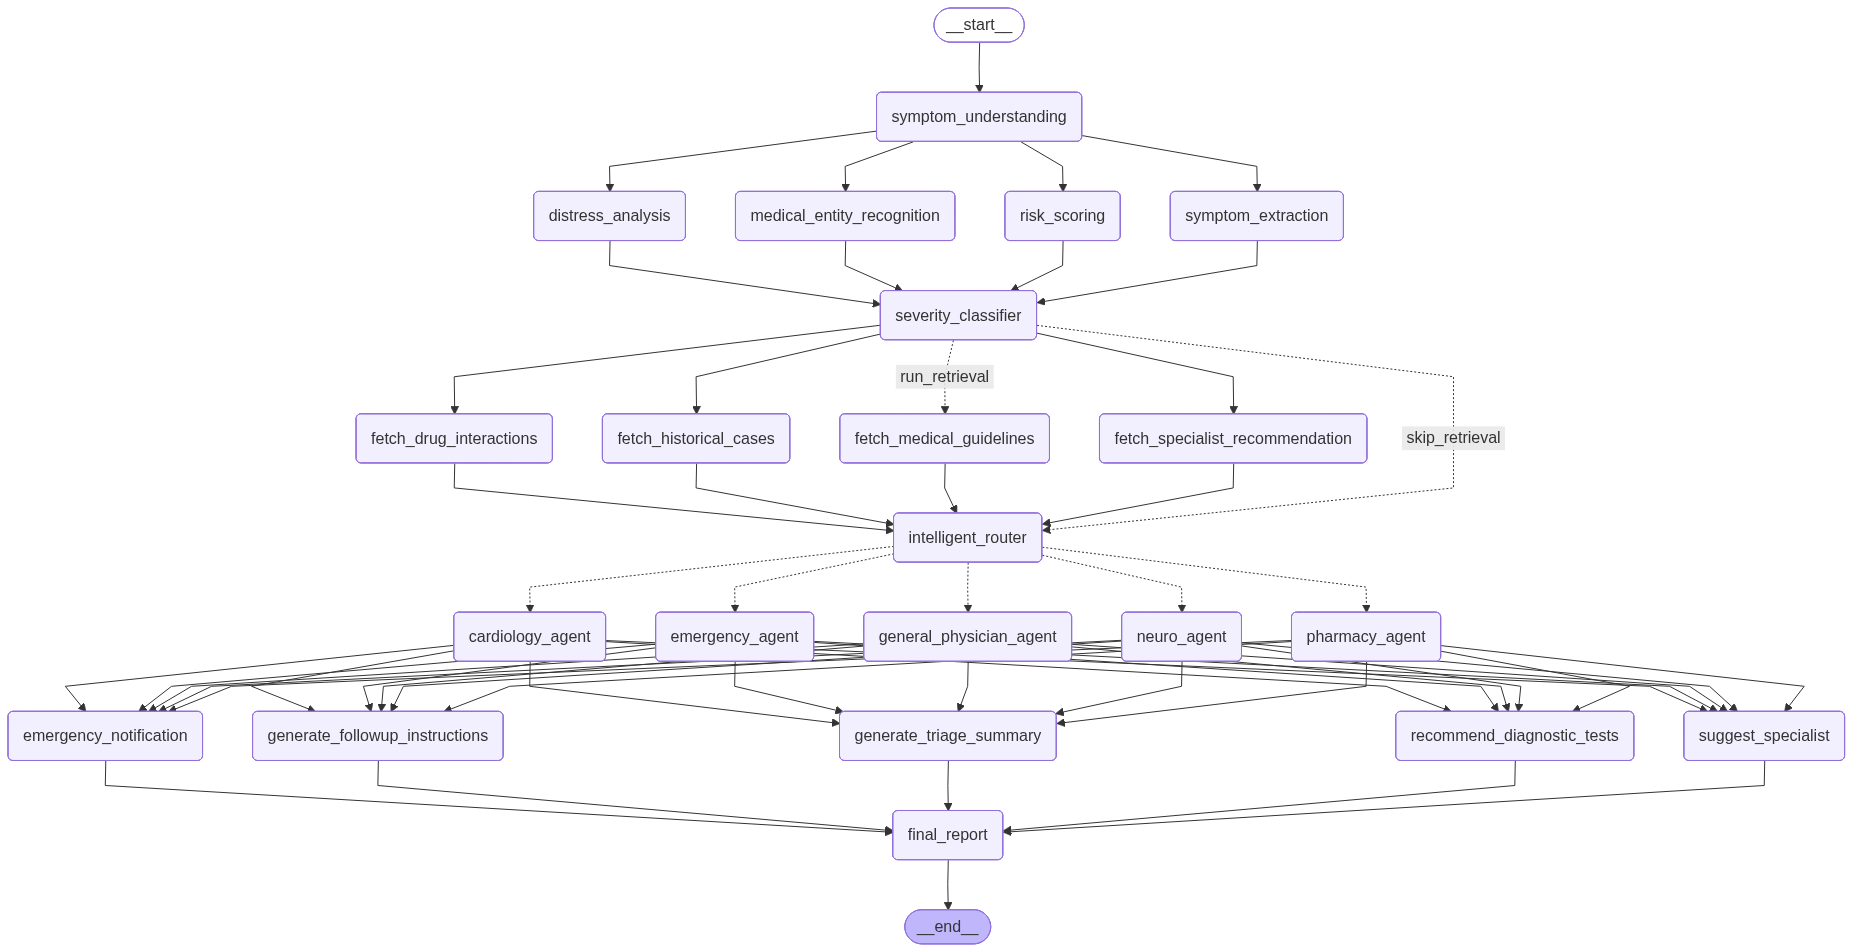

In [194]:
clinical_workflow


### Test Cases

In [195]:
#Test Case 1: Emergency — Cardiac
print("=" * 70)
print("TEST CASE 1: Chest pain and shortness of breath")
print("=" * 70)

result_1 = clinical_workflow.invoke({
    "symptoms_text": "Chest pain and shortness of breath.",
    "patient_history": "Hypertension, takes aspirin and blood pressure medication."
})

TEST CASE 1: Chest pain and shortness of breath

╔══════════════════════════════════════════════════════════════════╗
║          CLINICAL TRIAGE & CARE COORDINATION REPORT             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — TRIAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRIAGE SUMMARY
Patient Complaint : Chest pain and shortness of breath.
Symptoms Identified:   • Chest pain
  • Shortness of breath
Severity Level    : CRITICAL
Risk Score        : 100/100
Emergency Flag    : YES
Patient Distress  : HIGH
Category          : CARDIAC
Assigned To       : Emergency Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — MEDICAL KNOWLEDGE RETRIEVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Guidelines      : N/A

Drug Flags      : No drug interactions flagged based on reported information.

Historical Re

In [196]:
#Test Case 2: General — Fever & Headache
print("=" * 70)
print("TEST CASE 2: Fever and headache for 3 days")
print("=" * 70)

result_2 = clinical_workflow.invoke({
    "symptoms_text": "Fever and headache for 3 days.",
    "patient_history": "No significant history."
})

TEST CASE 2: Fever and headache for 3 days

╔══════════════════════════════════════════════════════════════════╗
║          CLINICAL TRIAGE & CARE COORDINATION REPORT             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — TRIAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRIAGE SUMMARY
Patient Complaint : Fever and headache for 3 days.
Symptoms Identified:   • Fever
  • Headache
Severity Level    : MEDIUM
Risk Score        : 50/100
Emergency Flag    : No
Patient Distress  : MODERATE
Category          : GENERAL
Assigned To       : General Physician Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — MEDICAL KNOWLEDGE RETRIEVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Guidelines      : General Triage Guidelines: Vital signs — BP, HR, Temperature, SpO2. Symptom duration and progression assessment. Pa

In [197]:
#Test Case 3: Pharmacy — Medication Reaction
print("=" * 70)
print("TEST CASE 3: Mild skin rash after medication")
print("=" * 70)

result_3 = clinical_workflow.invoke({
    "symptoms_text": "Mild skin rash after medication. Started after taking penicillin.",
    "patient_history": "No known allergies on file. Recently prescribed antibiotic."
})

TEST CASE 3: Mild skin rash after medication

╔══════════════════════════════════════════════════════════════════╗
║          CLINICAL TRIAGE & CARE COORDINATION REPORT             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — TRIAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRIAGE SUMMARY
Patient Complaint : Mild skin rash after medication. Started after taking penicillin.
Symptoms Identified:   • skin rash
  • medication reaction
Severity Level    : LOW
Risk Score        : 0/100
Emergency Flag    : No
Patient Distress  : LOW
Category          : MEDICATION_REACTION
Assigned To       : Pharmacy Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — MEDICAL KNOWLEDGE RETRIEVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Guidelines      : Allergy & Anaphylaxis Protocol: Assess for anaphylaxis — epinephrine 

In [198]:
#Test Case 4: Neuro — Dizziness & Blurred Vision
print("=" * 70)
print("TEST CASE 4: Sudden dizziness and blurred vision")
print("=" * 70)

result_4 = clinical_workflow.invoke({
    "symptoms_text": "Sudden dizziness and blurred vision. Started 30 minutes ago.",
    "patient_history": "Diabetes (on metformin). No prior neurological history."
})

TEST CASE 4: Sudden dizziness and blurred vision

╔══════════════════════════════════════════════════════════════════╗
║          CLINICAL TRIAGE & CARE COORDINATION REPORT             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — TRIAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRIAGE SUMMARY
Patient Complaint : Sudden dizziness and blurred vision. Started 30 minutes ago.
Symptoms Identified:   • dizziness
  • blurred vision
  • sudden onset
Severity Level    : CRITICAL
Risk Score        : 100/100
Emergency Flag    : YES
Patient Distress  : HIGH
Category          : NEURO
Assigned To       : Emergency Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — MEDICAL KNOWLEDGE RETRIEVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Guidelines      : N/A

Drug Flags      : No drug interactions flagged based on r